# Text Representation

Text representation in NLP means converting text into a numerical form that a machine learning model can understand and process.

## What is Embedding?

Embeddings in NLP is a technique where individual words are represented as real-valued vectors and captures inter-word semantics.


In this notebook, We going to intreduce 2 techniques for embedding. These techniques will be used for a machine learning models such as SVM, Random forest, ... ect.

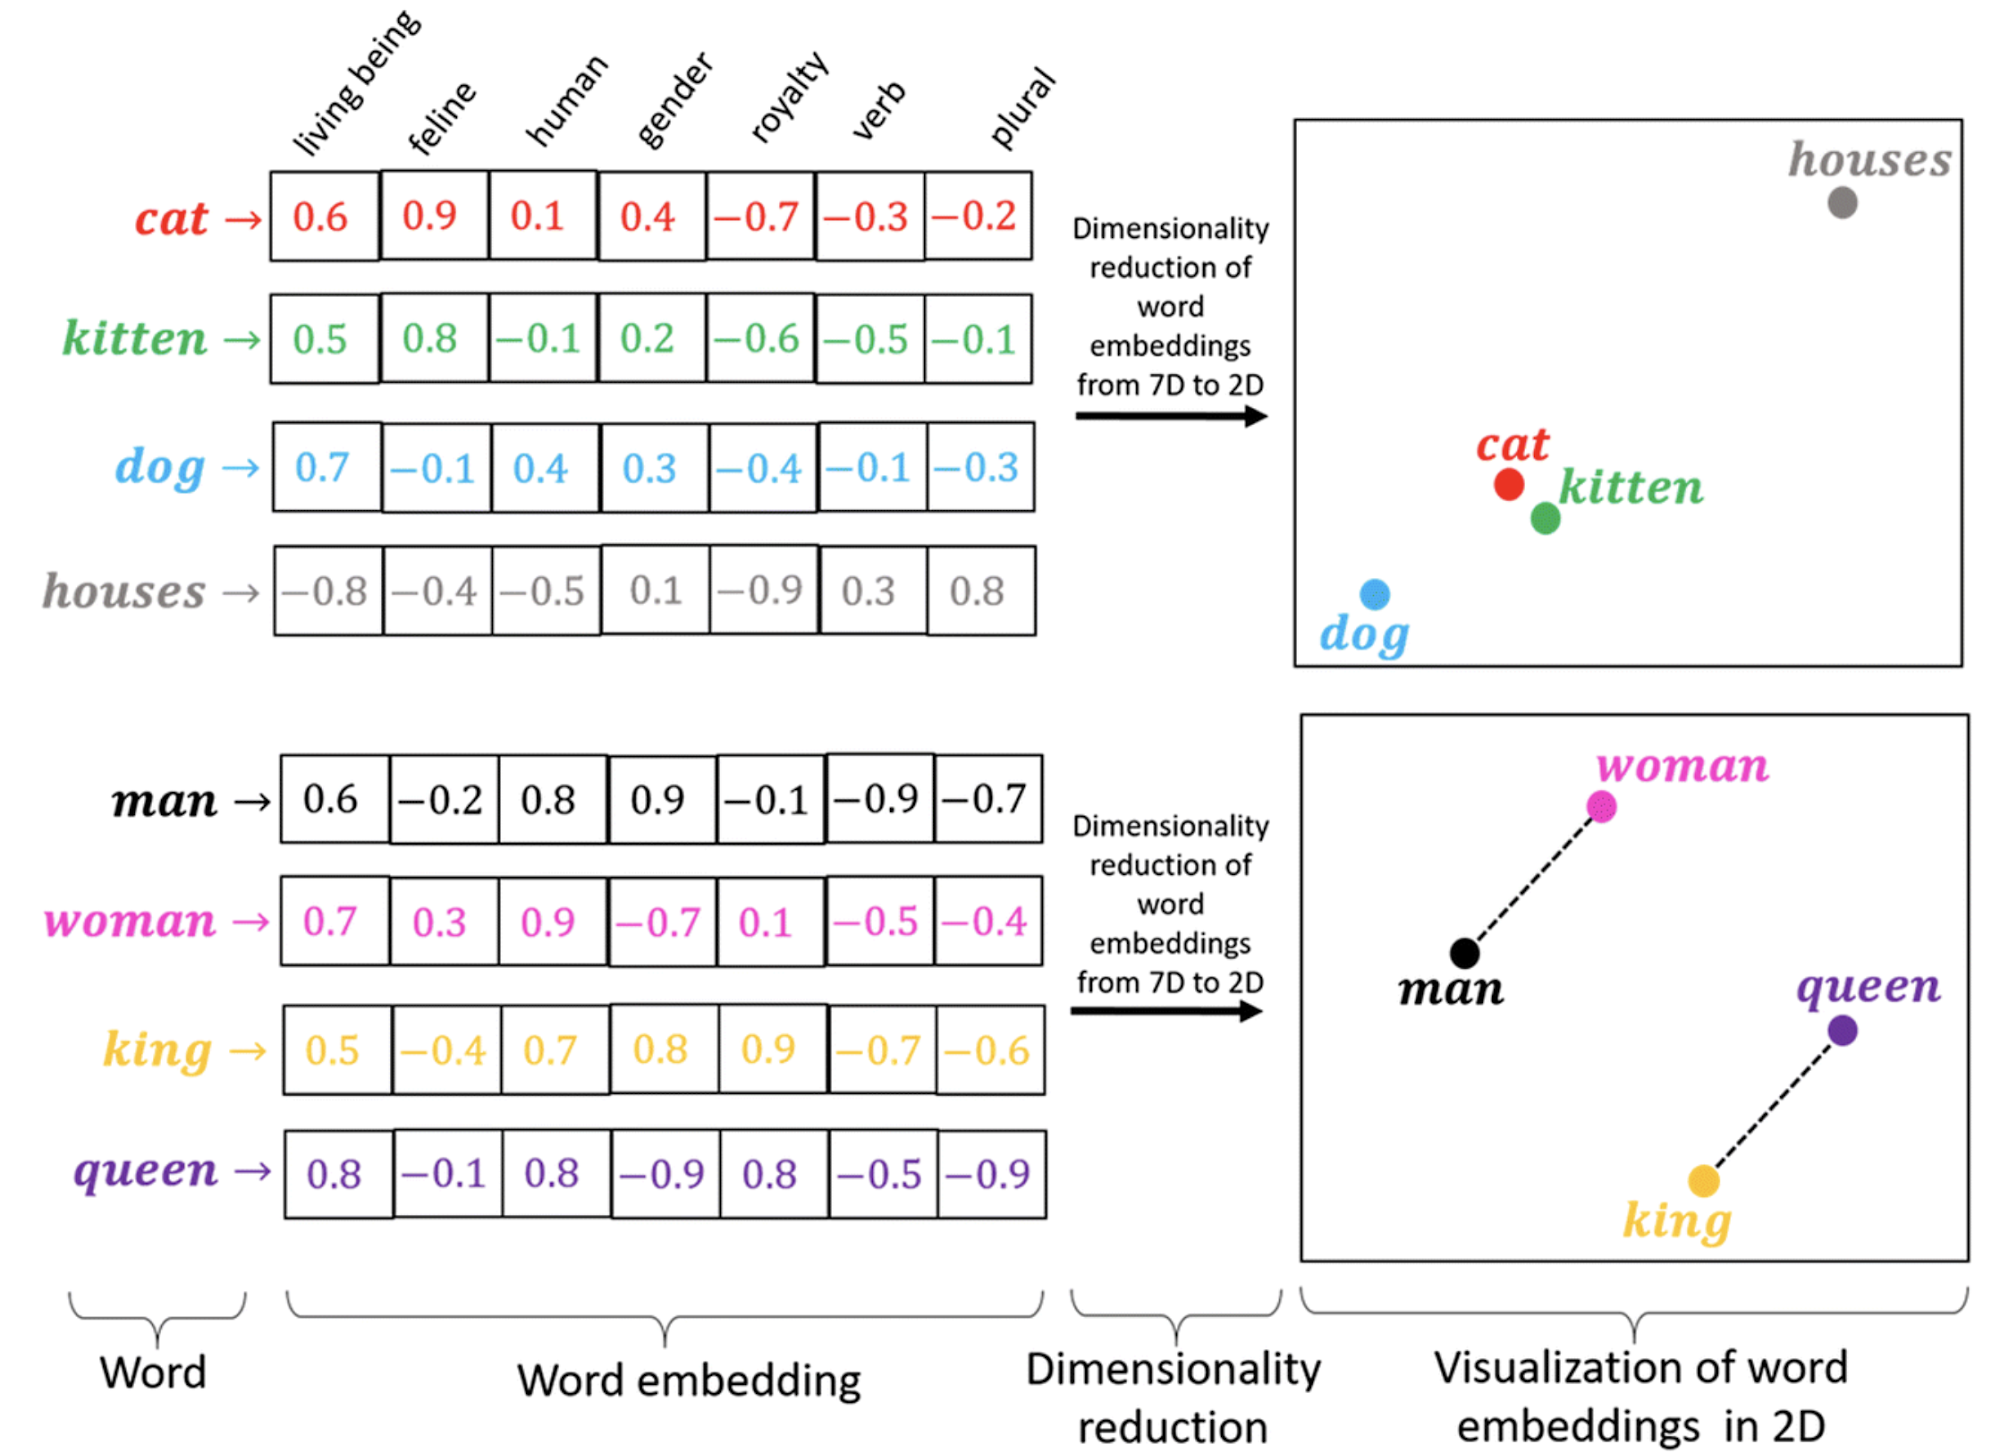

# 1- TF-IDF

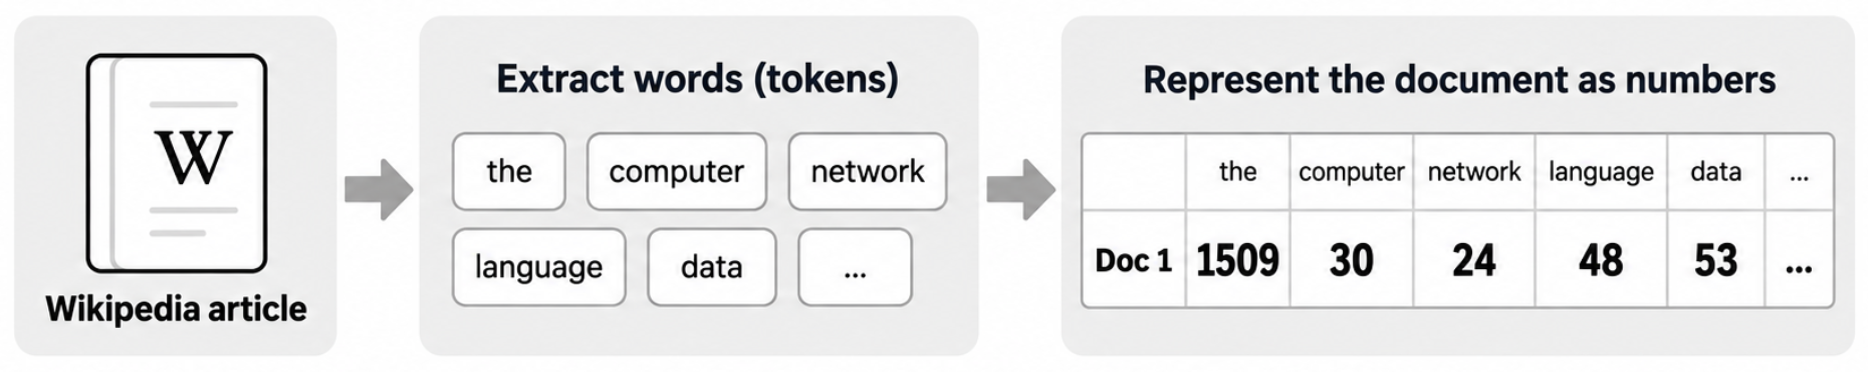

TF-IDF stands for term frequency-inverse document frequency. It is a measure that discounts common words. Used in the fields of information retrieval (IR) and machine learning, that can quantify the importance of words in a document amongst a collection of documents (also known as a corpus).

### Components of TF-IDF

1. **TF (Term Frequency):**  
   Measures how frequently a term appears in a document.


$$ \text{TF}(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d} $$


2. **IDF (Inverse Document Frequency):**  
   Measures how important a term is across all documents. Words that appear in many documents get lower scores.

$$    \text{IDF}(t) = \log \left(\frac{\text{Number of all documents N}}{\text{Number of documents containing the term } t}\right) $$

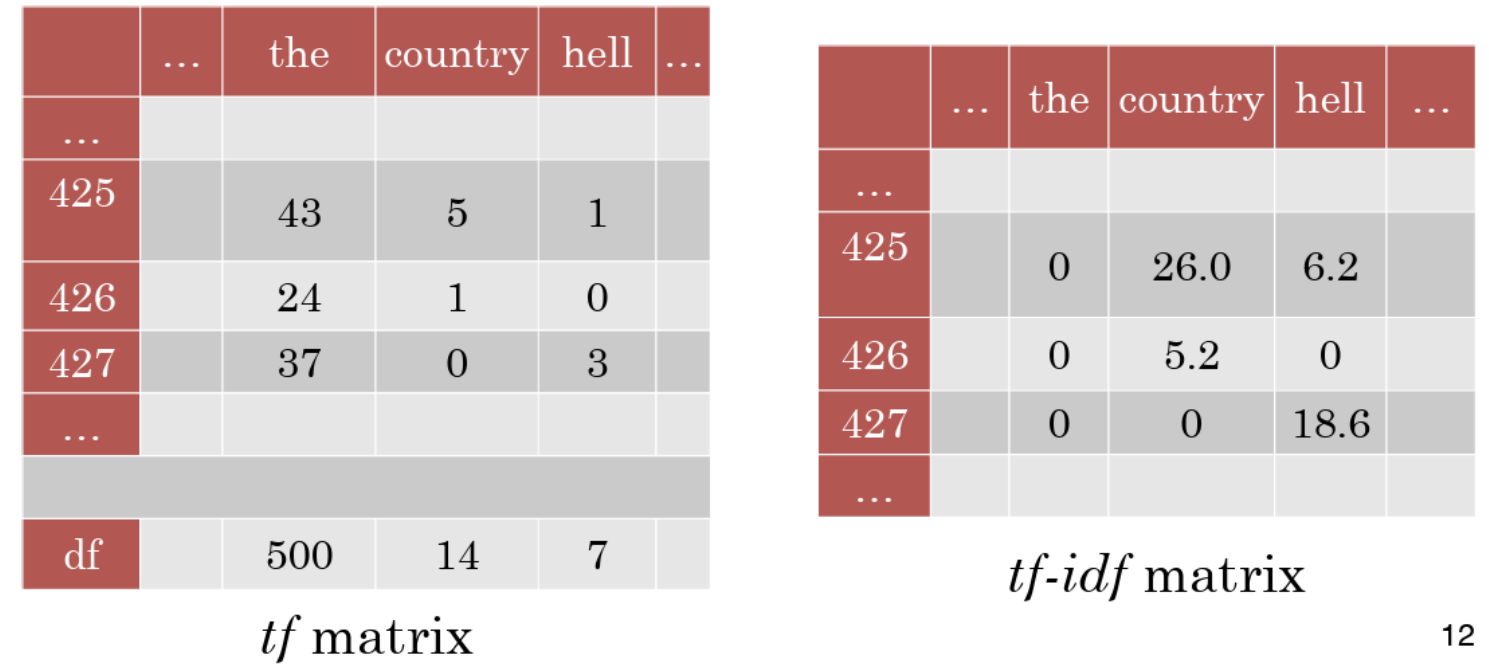

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

In [12]:
doc_1 = "Data is the oil of the digital economy"
doc_2 = "Data is a new oil"

data = [doc_1, doc_2]


In [18]:
tfidf = TfidfVectorizer()
result = tfidf.fit_transform(data) # returns sparce matrix

In [19]:
df = pd.DataFrame(result.toarray(), columns=tfidf.get_feature_names_out())
df

,data,digital,economy,is,new,of,oil,the
0,0.243777,0.34262,0.34262,0.243777,0.000000,0.34262,0.243777,0.68524
1,0.448321,0.00000,0.00000,0.448321,0.630099,0.00000,0.448321,0.00000


# Cosine similarity

In NLP, Cosine similarity is a metric used to measure how similar the documents are.


$$ \text{cosine similarity} = \frac{A \cdot B}{\|A\| \times \|B\|} $$

Where:  
$ A \cdot B $  = dot product of vectors A and B  
$ \|A\| $ = magnitude (length) of vector A  
$ \|B\| $ =  magnitude (length) of vector B

#### Intuition

- If vectors point in the **same direction**, cosine similarity = **1** (maximum similarity).
- If vectors are **orthogonal (90° apart)**, cosine similarity = **0** (no similarity).

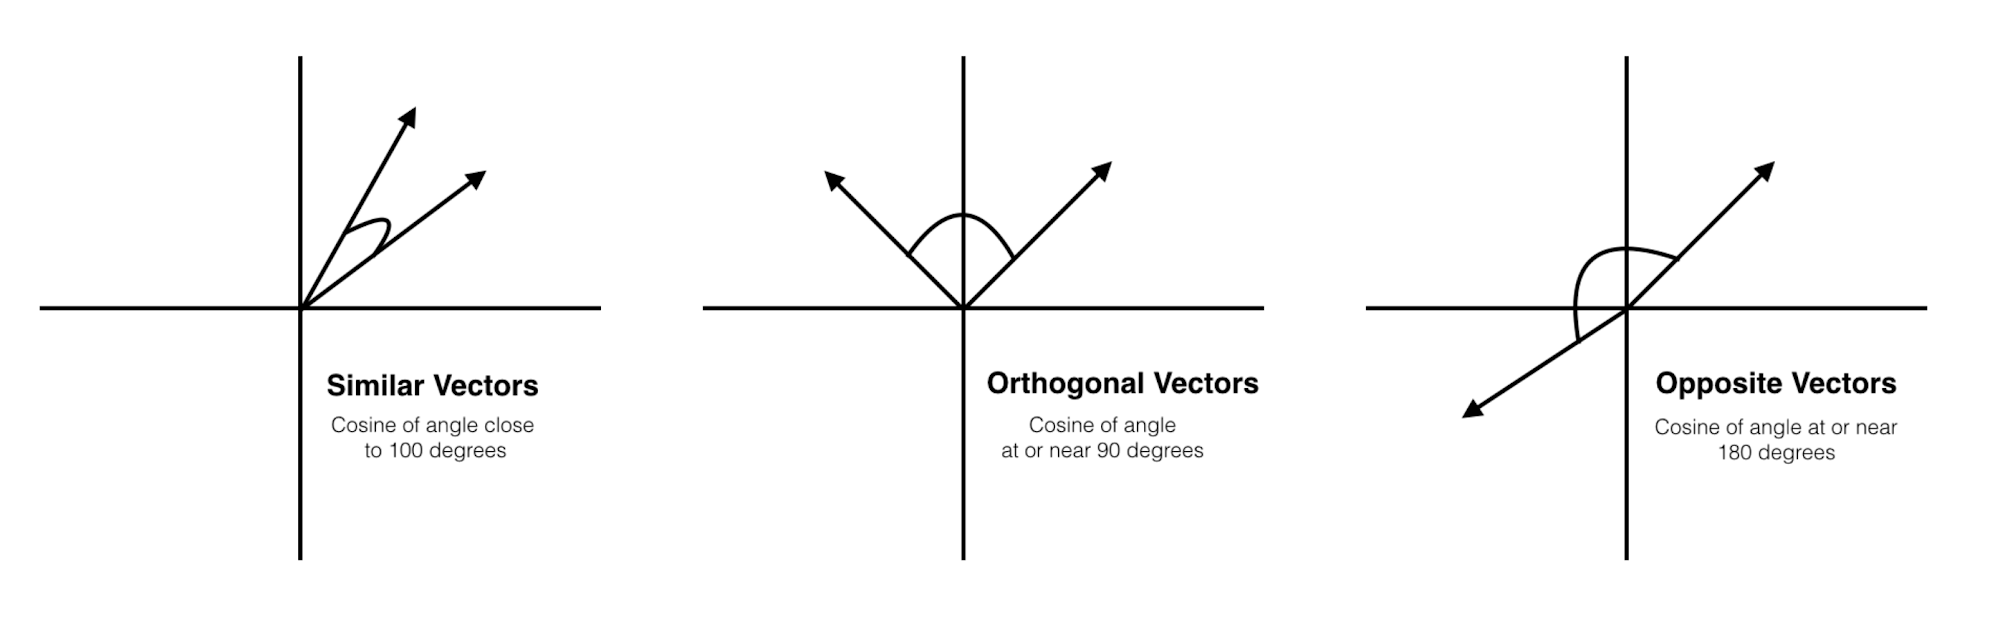

In [22]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [23]:
# Sample text data (replace with your own documents)

doc_1 = "Data is the oil of the digital economy"
doc_2 = "Data is a new oil"

data = [doc_1, doc_2]

In [24]:
tfidf_vectorizer = TfidfVectorizer() # Create a CountVectorizer instance
vector_matrix = tfidf_vectorizer.fit_transform(data) # Fit and transform the documents into numerical vectors

In [27]:
# Calculate the cosine similarity between the documents
cosine_similarity_matrix = cosine_similarity(vector_matrix)

df_cosine = pd.DataFrame(data=cosine_similarity_matrix, index=data, columns=data)

df_cosine

,Data is the oil of the digital economy,Data is a new oil
Data is the oil of the digital economy,1.000000,0.327871
Data is a new oil,0.327871,1.000000


# 2- What is Word2vec?

Word2Vec consists of models for generating word embedding. These models are two-layer neural networks having one input layer, one hidden layer, and one output layer.

Word2Vec utilizes two architectures :
1. CBOW (Continuous Bag of Words)
2. **Skip Gram**
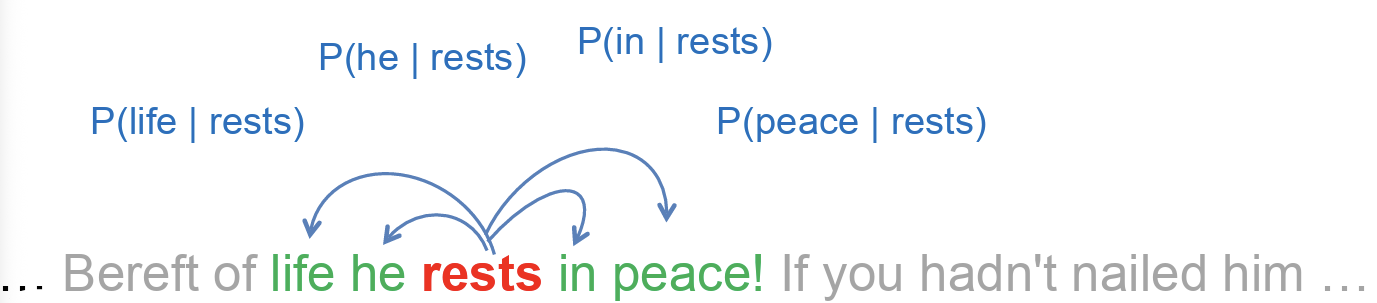


Run this command in terminal to install
> pip install gensim

We will use fake and real news dataset to do our expirament. You can find the dataset here: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset?select=True.csv


In [4]:
import pandas as pd
import nltk
import numpy as np
import gensim

from nltk.tokenize import word_tokenize

In [7]:
df = pd.read_csv('/content/True.csv', engine='python', on_bad_lines='skip') #fake-and-real-news-dataset-true.csv
df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [10]:
tokens = []

for i in df['text']:
    token = word_tokenize(i)
    tokens.append(token)

In [11]:
w2v = gensim.models.Word2Vec(tokens, min_count=1, vector_size=100, window=5, sg=1)

In [28]:
print("Cosine similarity between 'provide' and 'program' - Skip Gram : ",w2v.wv.similarity('provide', 'program'))

Cosine similarity between 'provide' and 'program' - Skip Gram :  0.41992348


In [29]:
print("words that similar to 'program' - Skip Gram : ",w2v.wv.most_similar('program'))

words that similar to 'program' - Skip Gram :  [('programs', 0.7426663041114807), ('programme', 0.687917172908783), ('guest-worker', 0.6685435771942139), ('EB-5', 0.66179358959198), ('seniors', 0.6605323553085327), ('arsenal', 0.659981906414032), ('expanding', 0.6542479395866394), ('abolishing', 0.6510066390037537), ('plan', 0.6469865441322327), ('marketplaces', 0.6462255120277405)]


# Tasks

### Task 1: Cosine Similarity
Use the Cosine Similarity method to determine how similar the following sentences are.

'This is the first document.',  
'This document is the second document.',  
'And this is the third one.',  
'Is this the first document?'  


In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

docs = ['This is the first document.',
        'This document is the second document.',
        'And this is the third one.',
        'Is this the first document?']

In [2]:
tfidf_vectorizer = TfidfVectorizer()
vector_matrix = tfidf_vectorizer.fit_transform(docs)

cosine_similarity_matrix = cosine_similarity(vector_matrix)

df_cosine = pd.DataFrame(data=cosine_similarity_matrix, index=docs, columns=docs)
df_cosine

,This is the first document.,This document is the second document.,And this is the third one.,Is this the first document?
This is the first document.,1.000000,0.646926,0.307772,1.000000
This document is the second document.,0.646926,1.000000,0.225240,0.646926
And this is the third one.,0.307772,0.225240,1.000000,0.307772
Is this the first document?,1.000000,0.646926,0.307772,1.000000


### Task 2: TF-IDF
Use tf-idf method on the sentences below to determine the important words.

'data science is one of the most important fields of science',  
'this is one of the best data science courses',  
'data scientists analyze data'  


In [3]:
sentences = ['data science is one of the most important fields of science',
             'this is one of the best data science courses',
             'data scientists analyze data']

tfidf = TfidfVectorizer()
result = tfidf.fit_transform(sentences)

df_tfidf = pd.DataFrame(result.toarray(), columns=tfidf.get_feature_names_out())
df_tfidf

,analyze,best,courses,data,fields,important,is,most,of,one,science,scientists,the,this
0,0.000000,0.000000,0.000000,0.189526,0.320895,0.320895,0.244049,0.320895,0.488098,0.244049,0.488098,0.000000,0.244049,0.000000
1,0.000000,0.400294,0.400294,0.236420,0.000000,0.000000,0.304434,0.000000,0.304434,0.304434,0.304434,0.000000,0.304434,0.400294
2,0.542701,0.000000,0.000000,0.641055,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.542701,0.000000,0.000000


In [4]:
# The most important words (highest TF-IDF score) in each sentence
for i, sentence in enumerate(sentences):
    scores = df_tfidf.iloc[i].sort_values(ascending=False)
    print(f"Sentence {i+1}: '{sentence}'")
    print(scores[scores > 0].head(3).round(4).to_string())
    print()

Sentence 1: 'data science is one of the most important fields of science'
science    0.4881
of         0.4881
fields     0.3209

Sentence 2: 'this is one of the best data science courses'
best       0.4003
courses    0.4003
this       0.4003

Sentence 3: 'data scientists analyze data'
data          0.6411
analyze       0.5427
scientists    0.5427



## Word2vec

### Task 3:

Download the Simpsons dataset **(simpsons_script_lines.csv)** and apply the preprocessing procedure.  
Use the **'spoken_words'** column.
```
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[0-9]", '', text)
    text = re.sub(r"[)(,”“.’$-]", '', text)
    return text
```
Create a skip gram Word2Vec model as below.
```
Skip_gram_model = gensim.models.Word2Vec(tokens, min_count = 1, vector_size = 100, window = 5, sg = 1)

In [5]:
import re
import pandas as pd
import nltk
import gensim
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab', quiet=True)

df = pd.read_csv('simpsons_script_lines.csv')
df.head()

,raw_character_text,spoken_words
0,Miss Hoover,"No, actually, it was a little of both. Sometim..."
1,Lisa Simpson,Where's Mr. Bergstrom?
2,Miss Hoover,I don't know. Although I'd sure like to talk t...
3,Lisa Simpson,That life is worth living.
4,Edna Krabappel-Flanders,The polls will be open from now until the end ...


In [6]:
df = df.dropna(subset=['spoken_words'])
df.shape

(131855, 2)

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[0-9]", '', text)
    text = re.sub(r"[)(,”“.’$-]", '', text)
    return text

In [8]:
df['clean_words'] = df['spoken_words'].apply(clean_text)
df[['spoken_words', 'clean_words']].head()

,spoken_words,clean_words
0,"No, actually, it was a little of both. Sometim...",no actually it was a little of both sometimes ...
1,Where's Mr. Bergstrom?,where's mr bergstrom?
2,I don't know. Although I'd sure like to talk t...,i don't know although i'd sure like to talk to...
3,That life is worth living.,that life is worth living
4,The polls will be open from now until the end ...,the polls will be open from now until the end ...


In [9]:
tokens = []

for i in df['clean_words']:
    token = word_tokenize(i)
    tokens.append(token)

print(len(tokens))
print(tokens[:3])

131855
[['no', 'actually', 'it', 'was', 'a', 'little', 'of', 'both', 'sometimes', 'when', 'a', 'disease', 'is', 'in', 'all', 'the', 'magazines', 'and', 'all', 'the', 'news', 'shows', 'it', "'s", 'only', 'natural', 'that', 'you', 'think', 'you', 'have', 'it'], ['where', "'s", 'mr', 'bergstrom', '?'], ['i', 'do', "n't", 'know', 'although', 'i', "'d", 'sure', 'like', 'to', 'talk', 'to', 'him', 'he', 'did', "n't", 'touch', 'my', 'lesson', 'plan', 'what', 'did', 'he', 'teach', 'you', '?']]


In [10]:
Skip_gram_model = gensim.models.Word2Vec(tokens, min_count = 1, vector_size = 100, window = 5, sg = 1)

### Task 4

Use: wv.most_similar() method to :

1.	Find the words similar to “homer”.

2.	Find the words similar to “marge”.

3. Find the words similar to “bart”



In [11]:
print("Words similar to 'homer' - Skip Gram : ", Skip_gram_model.wv.most_similar('homer'))

Words similar to 'homer' - Skip Gram :  [('marge', 0.8746829032897949), ('abe', 0.864536464214325), ('eliza', 0.8293622136116028), ('grampa', 0.8027085661888123), ('bartholomew', 0.8017081618309021), ('mindy', 0.7993322610855103), ('bart', 0.7976808547973633), ('barney', 0.7958829998970032), ('jay', 0.7950683236122131), ('apu', 0.7945159077644348)]


In [12]:
print("Words similar to 'marge' - Skip Gram : ", Skip_gram_model.wv.most_similar('marge'))

Words similar to 'marge' - Skip Gram :  [('homer', 0.8746830224990845), ('abe', 0.8627532720565796), ('sweetie', 0.8508235216140747), ('sweetheart', 0.8400366306304932), ('eliza', 0.8334077596664429), ('apu', 0.8303643465042114), ('honey', 0.8268424868583679), ('allison', 0.8246230483055115), ('midge', 0.8192216157913208), ('lurleen', 0.8163812756538391)]


In [13]:
print("Words similar to 'bart' - Skip Gram : ", Skip_gram_model.wv.most_similar('bart'))

Words similar to 'bart' - Skip Gram :  [('milhouse', 0.8721207976341248), ('lisa', 0.8689641952514648), ('eliza', 0.8486171960830688), ('jessica', 0.8346066474914551), ('kirk', 0.832844078540802), ('sweetie', 0.8287116289138794), ('abe', 0.8274818062782288), ('saxophone', 0.8245131969451904), ('grampa', 0.8206693530082703), ('luann', 0.8197371363639832)]


### Task 5

Use the wv.doesnt_match() method to :

1.	Find which of 'jimbo', 'milhouse’, and 'kearney’ does not belong to the list.

3.	Find the odd one among "nelson", "bart", and "milhouse".

4.	Find the odd one among ‘homer', 'patty', and ‘selma'.

*Hint: You need to pass the strings as List*

In [14]:
print("Odd one among ['jimbo', 'milhouse', 'kearney'] : ", Skip_gram_model.wv.doesnt_match(['jimbo', 'milhouse', 'kearney']))

Odd one among ['jimbo', 'milhouse', 'kearney'] :  milhouse


In [15]:
print("Odd one among ['nelson', 'bart', 'milhouse'] : ", Skip_gram_model.wv.doesnt_match(['nelson', 'bart', 'milhouse']))

Odd one among ['nelson', 'bart', 'milhouse'] :  nelson


In [16]:
print("Odd one among ['homer', 'patty', 'selma'] : ", Skip_gram_model.wv.doesnt_match(['homer', 'patty', 'selma']))

Odd one among ['homer', 'patty', 'selma'] :  homer


# What I Learned

In this lab I learned how text can be turned into numbers so a model can work with it. Before this, I knew models need numeric input, but I didn't really think about how much the choice of representation changes the results.

With TF-IDF, I saw that a word's score depends on how often it shows up in a sentence and how rare it is across the other sentences. In Task 2, "data" appears in all three sentences, so in the first two sentences it got a low score. But in the third sentence it got the highest score (0.64) because it is repeated twice in a short sentence. Words like "best", "courses", "analyze" and "scientists" scored high because they only appear in one sentence. One thing I noticed is that common words like "of" and "this" can still get high scores in small examples like this, which is why stop word removal is usually done before TF-IDF.

In Task 1, I used cosine similarity on the TF-IDF vectors. The first and fourth sentences got a similarity of 1.0 even though one is a statement and the other is a question. That showed me that TF-IDF only looks at which words are used and ignores word order and punctuation, so it cannot tell the difference in meaning between them.

The Word2Vec part was different because the model learns the meaning of a word from the words around it. After training the skip-gram model on the Simpsons script, words like "marge" and "abe" (his dad) came at the top of the most similar words to "homer", and the closest word to "bart" was "milhouse", his best friend. The model was never told who these characters are, it learned the relations only from how they are used in the dialogue. The doesnt_match results also made sense: "homer" was picked as the odd one next to "patty" and "selma" (the two sisters), and "nelson" was picked next to "bart" and "milhouse".

I also learned that preprocessing affects the model. Lowercasing was important so that "Homer" and "homer" are treated as one word. I also noticed that the clean_text function does not remove "?" or "!", so word_tokenize kept them as separate tokens. Finally, the Word2Vec results can change a little every time the model is trained, since the training involves randomness, so the similarity scores are not exactly the same on each run.